## Project: Transfer Spending vs Club Financials

This project investigates whether clubs that generate more revenue also spend more on transfers, and looks at how transfer spending breaks down by playing position. Data covers thousands of transfers and club financial records from 2010 onwards, sourced from a Kaggle football transfers dataset.

In [15]:
from google.colab import files
uploaded = files.upload()

Saving record_transfers.csv to record_transfers (4).csv
Saving transfers_history.csv to transfers_history (4).csv


In [16]:
import pandas as pd

transfers = pd.read_csv('record_transfers.csv')
history = pd.read_csv('transfers_history.csv')

print("Record transfers shape:", transfers.shape)
print("Transfer history shape:", history.shape)

transfers.head()

Record transfers shape: (57, 13)
Transfer history shape: (14990, 19)


,transfer_id,date,year,season,player_name,position,age_at_transfer,from_club,to_club,fee_eur_m,is_free_transfer,is_loan,is_extension
0,R001,2009-07-01,2009,2009-2010,Cristiano Ronaldo,FW,24,Manchester United,Real Madrid,94.0,0,0,0
1,R002,2013-09-02,2013,2013-2014,Gareth Bale,LW,24,Tottenham,Real Madrid,100.0,0,0,0
2,R003,2014-07-15,2014,2014-2015,Luis Suarez,FW,27,Liverpool,FC Barcelona,82.0,0,0,0
3,R004,2014-08-31,2014,2014-2015,James Rodriguez,AM,23,Monaco,Real Madrid,80.0,0,0,0
4,R005,2016-07-04,2016,2016-2017,Gonzalo Higuain,FW,28,Napoli,Juventus,90.0,0,0,0


In [17]:
from google.colab import files
uploaded = files.upload()

Saving league_metrics.csv to league_metrics (2).csv


In [18]:
metrics = pd.read_csv('league_metrics.csv')
print(metrics.shape)
metrics.head()

(170, 8)


,year,league,country,num_teams,total_revenue_eur_m,avg_attendance,avg_ticket_eur,foreign_players_pct
0,2010,Premier_League,ENG,20,2450.0,40147,65,65
1,2011,Premier_League,ENG,20,2858.0,37109,65,65
2,2012,Premier_League,ENG,20,3186.0,41821,65,65
3,2013,Premier_League,ENG,20,3620.0,42198,65,65
4,2014,Premier_League,ENG,20,3975.0,39567,65,65


In [19]:
from google.colab import files
uploaded = files.upload()

Saving club_financials.csv to club_financials.csv


In [20]:
financials = pd.read_csv('club_financials.csv')
print(financials.shape)
financials.head()

(884, 10)


,year,club_name,league,country,stadium_capacity,revenue_eur_m,wage_bill_eur_m,wages_to_revenue_pct,net_transfer_spend_eur_m,operating_profit_eur_m
0,2010,Manchester City,Premier_League,ENG,55000,154.4,76.9,49.8,40.9,-2.0
1,2011,Manchester City,Premier_League,ENG,55000,221.2,100.1,45.2,65.0,0.8
2,2012,Manchester City,Premier_League,ENG,55000,278.1,148.5,53.4,22.8,37.2
3,2013,Manchester City,Premier_League,ENG,55000,330.4,196.3,59.4,93.1,-41.5
4,2014,Manchester City,Premier_League,ENG,55000,401.8,243.6,60.6,64.6,-6.9


### Does club revenue predict transfer spending?

Here I calculate the correlation between a club's revenue and their net transfer spend, then visualise the relationship with a scatter plot.


Correlation between revenue and transfer spend: 0.34


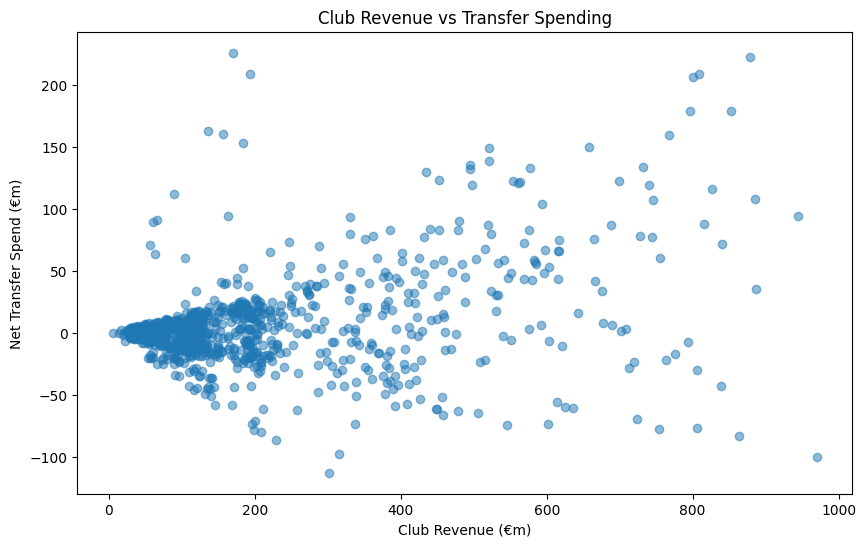

In [21]:
import matplotlib.pyplot as plt

correlation = financials['revenue_eur_m'].corr(financials['net_transfer_spend_eur_m'])
print(f"Correlation between revenue and transfer spend: {correlation:.2f}")

plt.figure(figsize=(10,6))
plt.scatter(financials['revenue_eur_m'], financials['net_transfer_spend_eur_m'], alpha=0.5)
plt.xlabel('Club Revenue (€m)')
plt.ylabel('Net Transfer Spend (€m)')
plt.title('Club Revenue vs Transfer Spending')
plt.show()

In [22]:
!pip install duckdb -q
import duckdb

# Register your dataframes so SQL can see them
duckdb.sql("SELECT * FROM financials LIMIT 5").show()

┌───────┬─────────────────┬────────────────┬─────────┬──────────────────┬───────────────┬─────────────────┬──────────────────────┬──────────────────────────┬────────────────────────┐
│ year  │    club_name    │     league     │ country │ stadium_capacity │ revenue_eur_m │ wage_bill_eur_m │ wages_to_revenue_pct │ net_transfer_spend_eur_m │ operating_profit_eur_m │
│ int64 │     varchar     │    varchar     │ varchar │      int64       │    double     │     double      │        double        │          double          │         double         │
├───────┼─────────────────┼────────────────┼─────────┼──────────────────┼───────────────┼─────────────────┼──────────────────────┼──────────────────────────┼────────────────────────┤
│  2010 │ Manchester City │ Premier_League │ ENG     │            55000 │         154.4 │            76.9 │                 49.8 │                     40.9 │                   -2.0 │
│  2011 │ Manchester City │ Premier_League │ ENG     │            55000 │         221

### Which clubs spend the highest proportion of their revenue on transfers?

Using SQL, I grouped transfer spend and revenue by club to find which clubs invest the largest share of their income into the transfer market.

In [23]:
query = """
SELECT
    club_name,
    ROUND(AVG(revenue_eur_m), 1) AS avg_revenue,
    ROUND(AVG(net_transfer_spend_eur_m), 1) AS avg_spend,
    ROUND(AVG(net_transfer_spend_eur_m) / AVG(revenue_eur_m) * 100, 1) AS spend_to_revenue_pct
FROM financials
GROUP BY club_name
ORDER BY spend_to_revenue_pct DESC
LIMIT 10
"""

duckdb.sql(query).show()

┌─────────────────────┬─────────────┬───────────┬──────────────────────┐
│      club_name      │ avg_revenue │ avg_spend │ spend_to_revenue_pct │
│       varchar       │   double    │  double   │        double        │
├─────────────────────┼─────────────┼───────────┼──────────────────────┤
│ Al-Nassr            │        54.6 │      31.0 │                 56.8 │
│ Al-Hilal            │        67.2 │      37.5 │                 55.8 │
│ Al-Ittihad          │        43.4 │      17.5 │                 40.4 │
│ Paris Saint-Germain │       511.1 │     100.9 │                 19.7 │
│ Newcastle United    │       199.7 │      37.7 │                 18.9 │
│ Manchester City     │       539.4 │      94.1 │                 17.4 │
│ Manchester United   │       563.2 │      91.1 │                 16.2 │
│ Chelsea             │       446.8 │      67.2 │                 15.0 │
│ Wolfsburg           │       138.8 │       6.3 │                  4.5 │
│ Fenerbahce          │        64.9 │       2.9 │  

### Which clubs are net sellers relative to their revenue?

The same query, flipped to find clubs that spend the smallest proportion of revenue — often "selling clubs" known for developing and selling talent.

In [24]:
query2 = """
SELECT
    club_name,
    ROUND(AVG(revenue_eur_m), 1) AS avg_revenue,
    ROUND(AVG(net_transfer_spend_eur_m), 1) AS avg_spend,
    ROUND(AVG(net_transfer_spend_eur_m) / AVG(revenue_eur_m) * 100, 1) AS spend_to_revenue_pct
FROM financials
GROUP BY club_name
ORDER BY spend_to_revenue_pct ASC
LIMIT 10
"""

duckdb.sql(query2).show()

┌─────────────┬─────────────┬───────────┬──────────────────────┐
│  club_name  │ avg_revenue │ avg_spend │ spend_to_revenue_pct │
│   varchar   │   double    │  double   │        double        │
├─────────────┼─────────────┼───────────┼──────────────────────┤
│ Benfica     │       145.5 │     -39.9 │                -27.4 │
│ RB Leipzig  │       167.9 │     -44.8 │                -26.7 │
│ Sporting CP │        64.0 │     -14.7 │                -22.9 │
│ Lille       │        85.3 │     -17.6 │                -20.6 │
│ Porto       │       120.0 │     -24.4 │                -20.3 │
│ Ajax        │       136.8 │     -26.4 │                -19.3 │
│ Fiorentina  │       140.8 │      -4.6 │                 -3.3 │
│ LAFC        │        53.6 │      -1.3 │                 -2.5 │
│ Inter Milan │       265.7 │      -5.2 │                 -1.9 │
│ Valencia    │       139.7 │      -2.7 │                 -1.9 │
├─────────────┴─────────────┴───────────┴──────────────────────┤
│ 10 rows                

### Where does transfer spending go by position?

This looks at total transfer spend and average fees broken down by playing position, to see which positions attract the most money.

In [25]:
query3 = """
SELECT
    position,
    COUNT(*) AS num_transfers,
    ROUND(AVG(fee_eur_m), 1) AS avg_fee,
    ROUND(SUM(fee_eur_m), 1) AS total_spent
FROM history
GROUP BY position
ORDER BY total_spent DESC
"""

duckdb.sql(query3).show()

┌──────────┬───────────────┬─────────┬─────────────┐
│ position │ num_transfers │ avg_fee │ total_spent │
│ varchar  │     int64     │ double  │   double    │
├──────────┼───────────────┼─────────┼─────────────┤
│ CB       │          3030 │    23.5 │     71236.0 │
│ CM       │          2736 │    22.8 │     62373.2 │
│ DM       │          1521 │    22.9 │     34774.6 │
│ AM       │          1496 │    23.0 │     34351.8 │
│ RB       │           999 │    26.1 │     26061.2 │
│ GK       │          1143 │    22.8 │     26008.9 │
│ LB       │          1109 │    23.0 │     25464.1 │
│ RW       │          1002 │    24.3 │     24357.3 │
│ LW       │          1040 │    22.1 │     22958.2 │
│ FW       │           914 │    23.1 │     21088.2 │
├──────────┴───────────────┴─────────┴─────────────┤
│ 10 rows                                4 columns │
└──────────────────────────────────────────────────┘



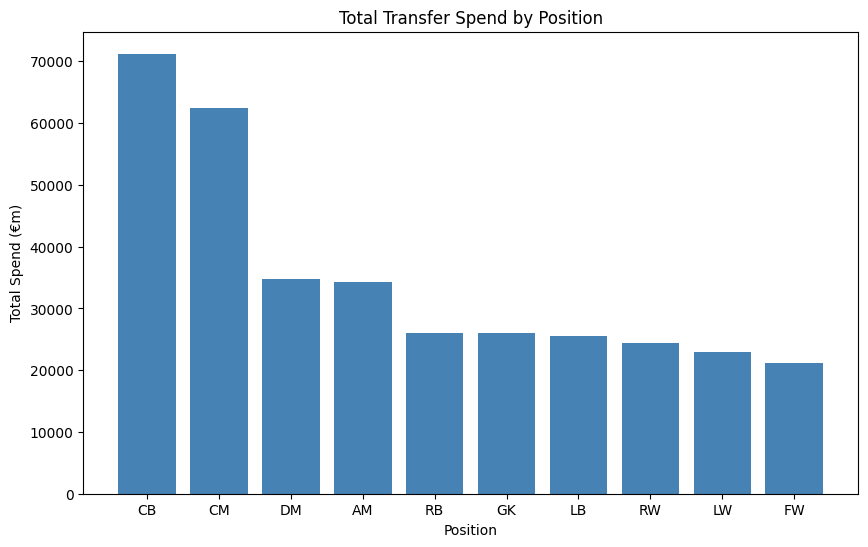

In [26]:
positions = duckdb.sql(query3).df()

plt.figure(figsize=(10,6))
plt.bar(positions['position'], positions['total_spent'], color='steelblue')
plt.xlabel('Position')
plt.ylabel('Total Spend (€m)')
plt.title('Total Transfer Spend by Position')
plt.show()